In [28]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [29]:
TRAIN_DIR = "../dataset/PlantVillage_5Class/train"
VAL_DIR = "../dataset/PlantVillage_5Class/val"

In [30]:
IMG_SIZE = (160,160)
BATCH_SIZE = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print(class_names)
print("Number of Classes:", len(class_names))

Found 4268 files belonging to 5 classes.
Found 1068 files belonging to 5 classes.
['Apple___Apple_scab', 'Apple___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Tomato___Late_blight']
Number of Classes: 5


In [31]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [32]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(160,160,3)
)

base_model.trainable = False

In [33]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    len(class_names),
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

In [34]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 166, 166,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 80, 80,    │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 80, 80,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 80, 80,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 82, 82,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 40, 40,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 40, 40,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 40, 40,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 40, 40,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 40, 40,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 40, 40,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 40, 40,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 40, 40,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 40, 40,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 40, 40,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 40, 40,    │     12,288 │ conv2_block2_0_r

 Total params: 7,301,189 (27.85 MB)

 Trainable params: 263,685 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping
import time

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

training_time = time.time() - start_time

print("Training Time:", training_time, "seconds")

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.7216 - loss: 1.3047 - val_accuracy: 0.9110 - val_loss: 0.2661
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - accuracy: 0.8969 - loss: 0.2965 - val_accuracy: 0.9335 - val_loss: 0.1872
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.9091 - loss: 0.2485 - val_accuracy: 0.9513 - val_loss: 0.1483
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.9372 - loss: 0.1871 - val_accuracy: 0.9494 - val_loss: 0.1516
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.9454 - loss: 0.1662 - val_accuracy: 0.9532 - val_loss: 0.1244
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9494 - loss: 0.1424 - val_accuracy: 0.9663 - val_loss: 0.1015
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.9557 - loss: 0.1228 - val_accuracy: 0.9719 - val_loss: 0.0836
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9555 - loss: 0.1255 - val_accuracy: 0.9569 - v

In [35]:
loss, accuracy = model.evaluate(val_ds)

print("Accuracy:", accuracy)
print("Loss:", loss)
print("Training Time:", training_time)

17/17 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.2865 - loss: 2.1785
Accuracy: 0.28651684522628784
Loss: 2.1785149574279785
Training Time: 2670.616087436676


In [36]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score
import numpy as np

y_true = np.concatenate([y for x, y in val_ds], axis=0)

predictions = model.predict(val_ds)

y_true_bin = label_binarize(
    y_true,
    classes=range(len(class_names))
)

mAP = average_precision_score(
    y_true_bin,
    predictions,
    average="macro"
)

print("mAP:", mAP)

14/17 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step

KeyboardInterrupt: 

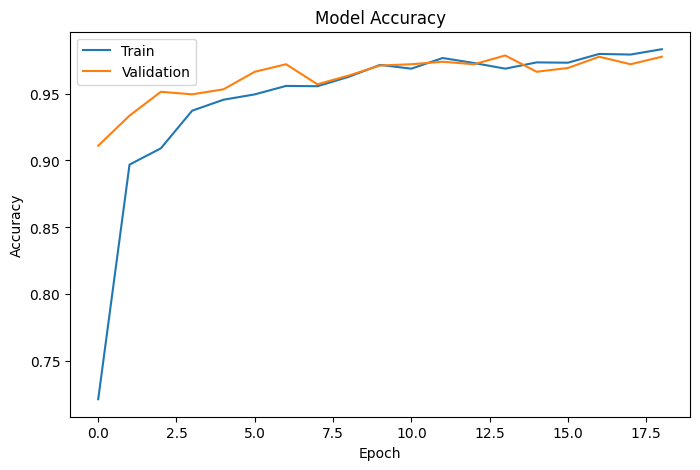

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.savefig("../results/model_accuracy.png")
plt.show()

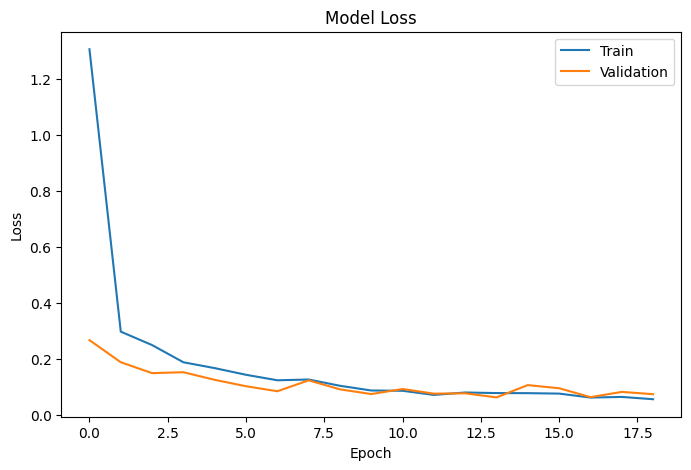

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.savefig("../results/model_loss.png")
plt.show()

In [17]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

17/17 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step


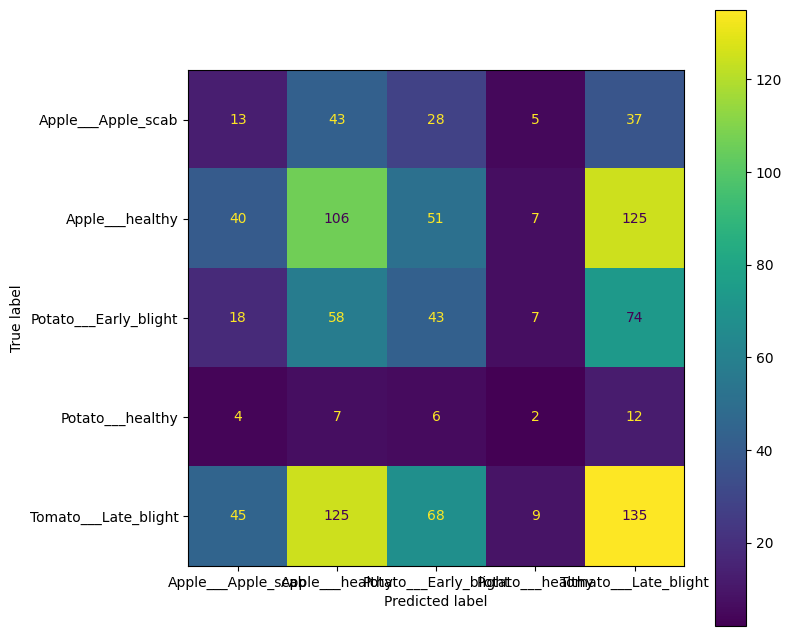

In [18]:
y_true = np.concatenate(
    [y for x, y in val_ds],
    axis=0
)

predictions = model.predict(val_ds)

y_pred = np.argmax(
    predictions,
    axis=1
)

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax)

plt.show()

In [ ]:
plt.savefig("results/confusion_matrix_mobilenetv3.png", dpi=300, bbox_inches="tight")

In [39]:
import os
os.makedirs("results", exist_ok=True)

fig.savefig("results/confusion_matrix_densenet.png", dpi=300, bbox_inches="tight")

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

In [20]:
y_true_bin = label_binarize(
    y_true,
    classes=range(len(class_names))
)

mAP = average_precision_score(
    y_true_bin,
    predictions,
    average="macro"
)

print("mAP:", mAP)

mAP: 0.20246787541122382


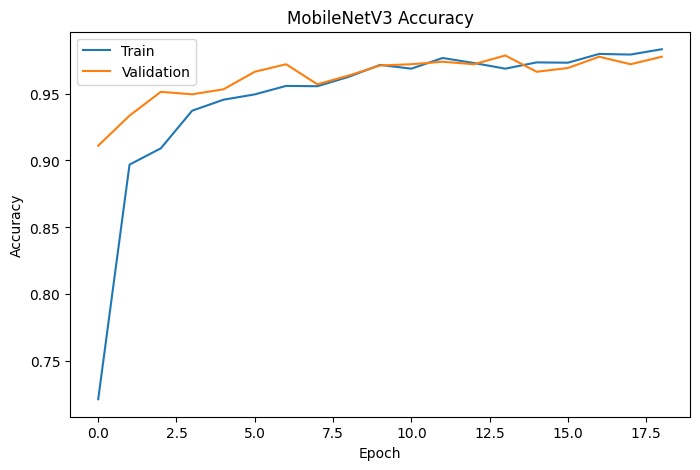

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('MobileNetV3 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

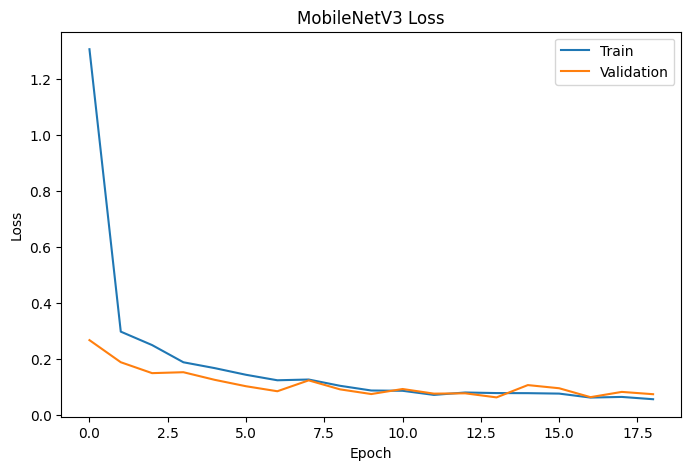

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('MobileNetV3 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

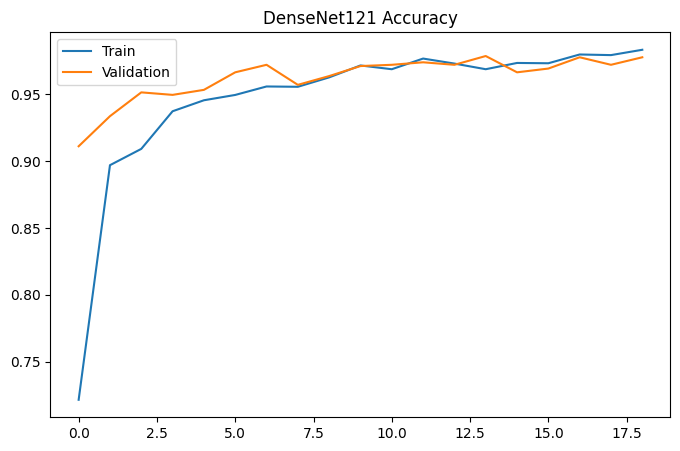

In [23]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('DenseNet121 Accuracy')
plt.legend(['Train','Validation'])

plt.savefig("../results/densenet_accuracy.png")
plt.show()

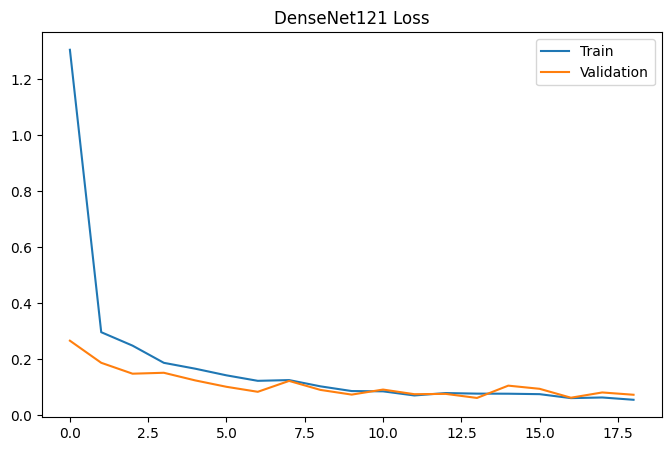

In [24]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('DenseNet121 Loss')
plt.legend(['Train','Validation'])

plt.savefig("../results/densenet_loss.png")
plt.show()

In [25]:
pd.DataFrame(history.history).to_csv(
    "../results/densenet121_history.csv",
    index=False
)

In [26]:
model = tf.keras.models.load_model("../models/mobilenetv3.keras")

In [38]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create folder
os.makedirs("results", exist_ok=True)

# True labels
y_true = np.concatenate([y for _, y in val_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

# Predictions
predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

# Save file
save_path = "results/confusion_matrix.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.close()  # important: prevents extra display in notebooks

AxisError: axis 1 is out of bounds for array of dimension 1